## Where do derivatives enter computation?

- To study any system one resorts to study changes in its states.

- if $f(t)$ gives certain feature of the system at any time $t$:
    - the difference $f(t_2) - f(t_1)$ would measure the change in system from $t_1$ to $t_2$

- to make further predictions about future what else can one study? 

- Consider a simple example, cooling of a hot object.
    - Suppose $T(t)$ is the temperature of a hot object.

        
| $t$ | 0 |1 | 2 | 3 | 4 |
| :--------- | :--------- | :--------- | :---------| :---------|:---------|
| $T(t)$       |100 |80 | 64 | 51.2 | 41  |

- we have tracked the state of the system as time progresses.
    - But just knowing these values doesn't immediately tell us how the system is evolving. 

#### Track how quickly the state is changing

- Calculate the change in temperature during each one-minute interval:
| $t$ | 0 $\to$ 1 |1 $\to$ 2 | 2 $\to$ 3 | 3 $\to$ 4 |
| :--------- | :--------- | :--------- | :---------| :---------|
| $\Delta T$       |-20 |-16 | -12.8 | -10.2 |

- Now we see something that the temperature values alone did not make obvious:
    - The hotter object cools faster, and as it cools, the rate of cooling becomes smaller.

- Can we use the rate to predict the next state?
    - Suppose we are at $t=2$
    - $T(2) = 64$
    - from the observations around this time $\frac{\Delta T}{\Delta t} = -12.8$
    - over a small time interval $\Delta t$, Taylor's series gives us:
        - $T(t + \Delta t ) \approx T(t) + \Delta t T^{\prime}(t)$
    - what is this $T^{\prime}(t)$?
    - $T^{\prime}(t) \approx \frac{\Delta T}{\Delta t}$
    - Now lets use it to get the value at $t = 3$
        - $T(3) = T(2) + 1 \times (-12.8) = 64 - 12.8 = 51.2$
      

- This is the computational viewpoint
    - $T(t) \to \frac{dT}{dt} \to T(t + \Delta t)$
    - $$ \boxed{ \text{State} \rightarrow \text{Rate of change} \rightarrow \text{Future state} } $$

- Until now we have come accross various methods demanding of derivatives:
    - Newton's method: $$ x_{k+1} = x_k - \frac{f(x_k)}{f^{\prime}(x_k)}$$
    - Steepest descent: $$x_{k+1} = x_k + \alpha \nabla f(x_k)$$
    - Newton line search: $$ x_{k+1} = x_k - H(x_k)^{-1} \nabla f(x_k)$$ 

### Suppose $f$ is available only as a computer program. 

- How do we obtain $f^{\prime}(x)$ or $\nabla f(x)$?

- A  simple, ellegant yet extremely efficient solution is :
    - ### Finite difference approximations

- we define derivative as: 
    $ f : \mathrm{R} \to \mathrm{R}$ is differentiale at $x_0$ is there is a number 
    denoted as $f^{\prime}(x_0)$ such that 
    $$ \lim_{h \to 0} \frac{f(x_0 + h) - f(x_0)}{h} = f^{\prime} (x_0)$$
    - $f^{\prime} (x_0)$ is called the derivative of $f$ at $x_0$.

- This immediately suggests us to approximate derivatives using forward differences:
    $$ f^{\prime}(x_0) \approx \frac{f(x_0 + h) - f(x_0)}{h}$$

- We define $D_h^+$ the forward difference operator with parameter $h$ as:
    $$ D_h^+ f(x_0) = \frac{f(x_0 + h) - f(x_0)}{h}$$
  
  - Forward difference error : $D_h^+ f(x_0) - f^{\prime}(x_0) = \mathcal{O}(h)$

- A better option might as well be central difference i.e. 
    $$D_h^c f(x_0) = \frac{f(x_0 + h) - f(x_0 - h)}{2h}$$

  - Central difference error : $D_h^+ f(x_0) - f^{\prime}(x_0) = \mathcal{O}(h^2)$

### Lets get on with this and perform some experiments

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Function and exact derivative
f = np.sin
x = 1.0
exact = np.cos(x)

In [10]:
# Step sizes
h_values = 10.0**(-np.arange(1, 17))
# print(h_values)

In [11]:
# forward difference approximation
f_errors = []
# Central difference approximation
c_errors = []

In [12]:
for h in h_values:
    derivative_f = (f(x + h) - f(x)) / (h)
    derivative_c = (f(x + h) - f(x - h)) / (2*h)

    f_error = abs(derivative_f - exact)
    f_errors.append(f_error)
    
    c_error = abs(derivative_c - exact)
    c_errors.append(c_error)

In [15]:
# Print results forward difference
for h, error in zip(h_values, f_errors):
    print(f"h = {h:.1e}, error = {error:.3e}")

h = 1.0e-01, error = 4.294e-02
h = 1.0e-02, error = 4.216e-03
h = 1.0e-03, error = 4.208e-04
h = 1.0e-04, error = 4.207e-05
h = 1.0e-05, error = 4.207e-06
h = 1.0e-06, error = 4.207e-07
h = 1.0e-07, error = 4.183e-08
h = 1.0e-08, error = 1.407e-08
h = 1.0e-09, error = 5.254e-08
h = 1.0e-10, error = 5.848e-08
h = 1.0e-11, error = 1.169e-06
h = 1.0e-12, error = 4.324e-05
h = 1.0e-13, error = 7.339e-04
h = 1.0e-14, error = 3.707e-03
h = 1.0e-15, error = 1.481e-02
h = 1.0e-16, error = 5.403e-01


In [16]:
# Print results Central difference
for h, error in zip(h_values, c_errors):
    print(f"h = {h:.1e}, error = {error:.3e}")

h = 1.0e-01, error = 9.001e-04
h = 1.0e-02, error = 9.005e-06
h = 1.0e-03, error = 9.005e-08
h = 1.0e-04, error = 9.004e-10
h = 1.0e-05, error = 1.114e-11
h = 1.0e-06, error = 2.772e-11
h = 1.0e-07, error = 1.943e-10
h = 1.0e-08, error = 2.970e-09
h = 1.0e-09, error = 2.970e-09
h = 1.0e-10, error = 5.848e-08
h = 1.0e-11, error = 1.169e-06
h = 1.0e-12, error = 1.227e-05
h = 1.0e-13, error = 1.788e-04
h = 1.0e-14, error = 3.707e-03
h = 1.0e-15, error = 1.481e-02
h = 1.0e-16, error = 1.481e-02


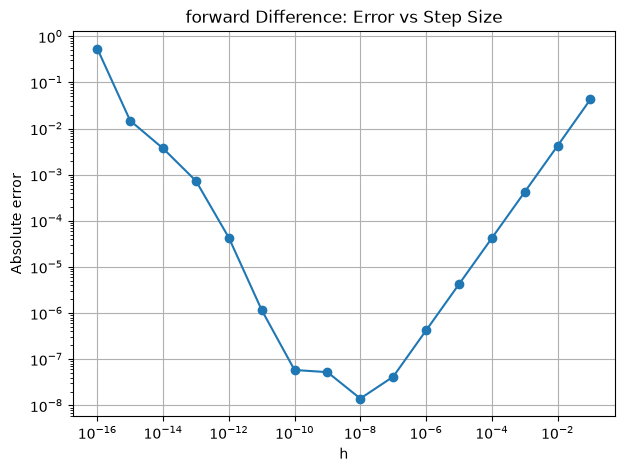

In [17]:
# Plot
plt.figure(figsize=(7, 5))
plt.loglog(h_values, f_errors, 'o-')
plt.xlabel("h")
plt.ylabel("Absolute error")
plt.title("forward Difference: Error vs Step Size")
plt.grid(True)
plt.show()

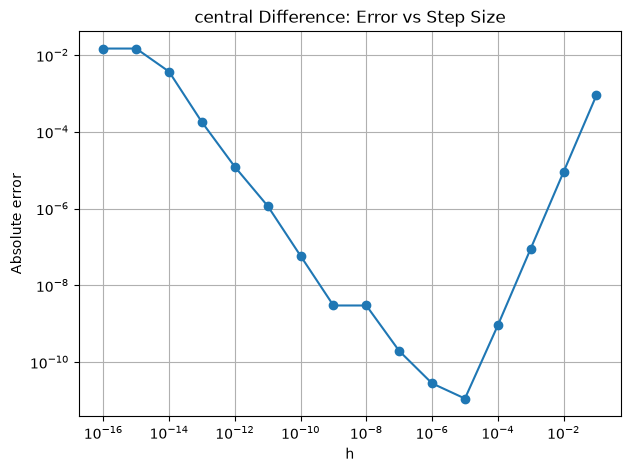

In [18]:
plt.figure(figsize=(7, 5))
plt.loglog(h_values, c_errors, 'o-')
plt.xlabel("h")
plt.ylabel("Absolute error")
plt.title("central Difference: Error vs Step Size")
plt.grid(True)
plt.show()

### what do we observe?
- The error initially decreases 

- what happens on a computer?

- Mathematically:  $ \ f(x + h) - f(x) \ $ is perfectly legitimate.

- But a computer does not store real numbers exactly.

- Instead $fl(x)=x(1+ \delta), \quad |\delta| \leq \varepsilon_{mach}$
- For IEEE double precision $\varepsilon_{mach} = 2.22 \times 10^{-6}$ 

- So the computer actually evaluates something closer to 
$$fl(f(x+h))−fl(f(x))$$.

- Suppose $h$ is very small.
    - We are subtracting two nearly equal numbers: $f(x+h) - f(x)$
    - The problem becomes particularly severe after division by $h$

- So there are two competing effects:
    - Large $h$ : Large truncation error.
    - Small $h$ : Large floating-point error.

- Mathematical limit $ \neq $ numerical computation of the limit

### A function is a sequence of operations

- Consider $f(x) = x^2 \sin(x)$

- Instead of viewing it as one complicated function, view the program as
  - $v_1 = x^2$
  - $v_2 = sin(x)$
  - $v_3 = v_1 \times v_2$

- Then $f = v_3$ 

- Each operation has a known derivative.

- Multiplication rule:
    - $f(x) = u(x) v(x)$
    - $f^{\prime}(x) = u^{\prime}(x) v(x) + u(x) v^{\prime}(x)$

- Chain rule:
    - $f(x) = g(h(x))$
    - $$\frac{df}{dx} = \frac{dg}{dh} \frac{dh}{dx}$$

## Exercise
- Consider the function $f(x) = (1 + x^2) \sin(2x)$
- Write a Python program that evaluates $f^{\prime}(x)$ at $x=1$.

- Do not use a finite-difference approximation
    - Break the function into intermediate quantities.
    - Identify which differentiation rules are needed.
    - Compute the derivative using the product rule and chain rule.
    - Print the value of $f'(1)$.

### Propagating derivative information

- We now want to turn the idea from the previous example into a systematic computational procedure.
- Suppose
  $$ u = u (x) $$
- Instead of carrying only the value $u$, we carry two pieces of information:
  $$ (u, \frac{du}{dx})$$
- the value and the derivative
  

- For the original variable $x$,
      $$x \to (x, \frac{dx}{dx}) \to (x, 1)$$ 

### Dual Numbers

- To systematically carry a value and its derivative together, we introduce a dual number.

- For a function $u(x)$, define
$$\hat{u} = u + u^{\prime} \varepsilon \qquad \qquad u^{\prime} = \frac{du}{dx}$$
- and $\varepsilon$ is a special number satisfying:
      $$ \varepsilon^2 = 0, \qquad \varepsilon \neq 0 $$

- Like complex number $i^2 = -1$.

- Thus dual numbers defined by $$z = x + \varepsilon y $$ form an algebra instead of a field, like in the case of complex numbers.

- if $z_1 = x_1 + \varepsilon y_1$ and $z_2 = x_2 + \varepsilon y_2$, then we have:
    $$\begin{align}
    z_1 \times z_2 &= (x_1+ \varepsilon y_1) (x_2 + \varepsilon y_2) \\
                    & = x_1 x_2 + \varepsilon (x_1 y_2 + x_2 y_1) + \varepsilon^2 y_1 y_2 
    \end{align}$$
    - but $\varepsilon^2 = 0$
    - Therefore we have
      $$ z_1 \times z_2  = x_1 x_2 + \varepsilon (x_1 y_2 + x_2 y_1)$$
      which is just the calculus of product rule


In [28]:
class Dual:
    def __init__(self, value, derivative):
        self.value = value
        self.derivative = derivative

    def __repr__(self):
        return f"{self.value} + {self.derivative}ε"

In [29]:
x = Dual(2.0, 1.0)

print(x)

2.0 + 1.0ε


- Addition

In [30]:
class Dual:
    def __init__(self, value, derivative):
        self.value = value
        self.derivative = derivative

    def __add__(self, other):
        return Dual(
            self.value + other.value,
            self.derivative + other.derivative
        )

    def __repr__(self):
        return f"{self.value} + {self.derivative}ε"

In [31]:
x = Dual(2.0, 1.0)
y = Dual(3.0, 0.0)

z = x + y

print(z)

5.0 + 1.0ε


- Multiplication

In [33]:
# def __mul__(self, other):
#        return Dual(
#            self.value * other.value,
#            self.derivative * other.value
#            + self.value * other.derivative
#        )

In [34]:
class Dual:
    def __init__(self, value, derivative):
        self.value = value
        self.derivative = derivative

    def __add__(self, other):
        return Dual(
            self.value + other.value,
            self.derivative + other.derivative
        )

    def __mul__(self, other):
        return Dual(
            self.value * other.value,
            self.derivative * other.value
            + self.value * other.derivative
        )

    def __repr__(self):
        return f"{self.value} + {self.derivative}ε"

In [35]:
x = Dual(2.0, 1.0)

f = x * x

print(f)

4.0 + 4.0ε


In [38]:
x = Dual(2.0, 1.0)

f = x * x + 3 * x + 1

print(f)

TypeError: unsupported operand type(s) for *: 'int' and 'Dual'

- this requires us to handle multiplication by ordinary numbers and addition with ordinary numbers.

In [39]:
class Dual:
    def __init__(self, value, derivative):
        self.value = value
        self.derivative = derivative

    def __add__(self, other):
        if isinstance(other, Dual):
            return Dual(
                self.value + other.value,
                self.derivative + other.derivative
            )
        else:
            return Dual(
                self.value + other,
                self.derivative
            )

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        if isinstance(other, Dual):
            return Dual(
                self.value * other.value,
                self.derivative * other.value
                + self.value * other.derivative
            )
        else:
            return Dual(
                self.value * other,
                self.derivative * other
            )

    def __rmul__(self, other):
        return self * other

    def __repr__(self):
        return f"{self.value} + {self.derivative}ε"

In [40]:
x = Dual(2.0, 1.0)

f = x * x + 3 * x + 1

print(f)

11.0 + 7.0ε


## the chain rule

In [44]:
class Dual:
    def __init__(self, value, derivative):
        self.value = value
        self.derivative = derivative

    def __add__(self, other):
        if isinstance(other, Dual):
            return Dual(
                self.value + other.value,
                self.derivative + other.derivative
            )
        else:
            return Dual(
                self.value + other,
                self.derivative
            )

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        if isinstance(other, Dual):
            return Dual(
                self.value * other.value,
                self.derivative * other.value
                + self.value * other.derivative
            )
        else:
            return Dual(
                self.value * other,
                self.derivative * other
            )

    def __rmul__(self, other):
        return self * other

    def __repr__(self):
        return f"{self.value} + {self.derivative}ε"

    def sin(self):
        return Dual(
            np.sin(self.value),
            np.cos(self.value) * self.derivative
        )

In [46]:
x = Dual(2.0, 1.0)

f = (x*x).sin()   # f(x) = sin(x^2)

print(f)

-0.7568024953079283 + -2.6145744834544478ε


In [ ]:
# Exercise
# f(x)=exp(x^2sinx)+sin(e^x+x^3)
# AD vs FD